<a href="https://colab.research.google.com/github/shehanimavindi/mlarena-student-pass-prediction/blob/main/ML_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview: 
  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  
0                  3                             72  
1                  3                             56  
2                  3                             56  
3             

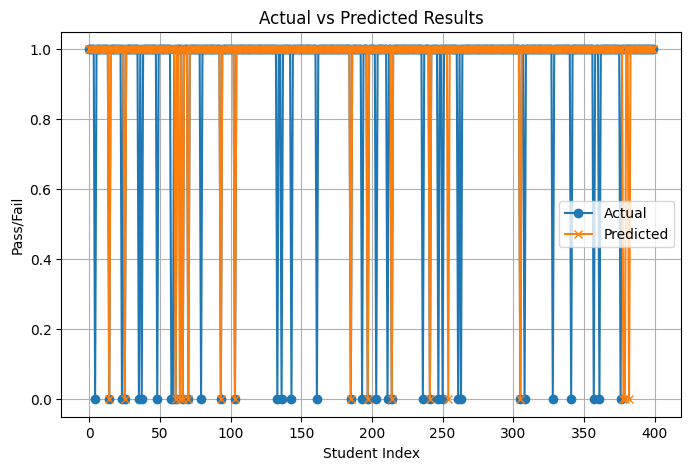

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report #Import required libraries

#Load the dataset and display the first few rows of the dataset
df = pd.read_csv(r"Final_Marks_Data (1).csv")
print("Dataset Preview: ")
print(df.head())

#Create Pass/Fail target column based on the final exam marks
df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 1 if x >= 50 else 0
)

#Features and Target
X = df[['Attendance (%)', 'Daily Study Hours']]
y = df['Result']

#Normalize feature values using StandardScaler
scalar =StandardScaler()
X = scalar.fit_transform(X)

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

#Predict results for test data
y_pred = model.predict(X_test)

#Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100}%")

#Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Visualize Actual vs Predicted results
plt.figure(figsize=(8,5))

plt.plot(range(len(y_test)), y_test.values,
         marker='o', label='Actual')

plt.plot(range(len(y_pred)), y_pred,
         marker='x', label='Predicted')

plt.title('Actual vs Predicted Results')
plt.xlabel('Student Index')
plt.ylabel('Pass/Fail')
plt.legend()
plt.grid(True)

plt.show()